Кластеризация данных

1. Импортировать датасет для кластеризации, т.е. либо без целевого признака, либо исключить целевой признак(Исходные данные можно выбрать:
- самостоятелно на kaggle.com;
- взять один из файлов, прикрепленных к заданию
- взять учебный набор данных из sklearn, например load_wine).
2. Очистить датасет от пропусков и выбросов, если они они есть, выполнить нормализацию, либо стандартизацию данных, если необходимо.
3. Если необходимо применить понижение размерности при помощи PCA и/или t-SNE.
4. Создать несколько моделей кластеризации, используя разные алгоритмы кластеризации (DBSCAN, иерархическую кластеризацию, k-means и др.)
5. Подобрать оптимальное количество кластеров.
6. Оценить качество кластеризации.


1. Импорт библиотек и данных

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

%matplotlib inline

# Загружаем данные
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target  # только для анализа (в кластеризацию не подаём)

print("Размер данных:", X.shape)
X.head()


Размер данных: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


2. Проверка пропусков, выбросов

In [5]:
print("Количество пропусков по признакам:")
print(X.isna().sum())

Количество пропусков по признакам:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


3. Пайплайн предобработки (импьютер → стандартизация → PCA)

In [6]:
preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))   # сразу понижаем до 2 измерений
])

X_pca = preprocess.fit_transform(X)
print("Доля объяснённой дисперсии компонентами PCA:",
      preprocess.named_steps['pca'].explained_variance_ratio_)
print("Суммарно:", preprocess.named_steps['pca'].explained_variance_ratio_.sum())


Доля объяснённой дисперсии компонентами PCA: [0.36198848 0.1920749 ]
Суммарно: 0.5540633835693526


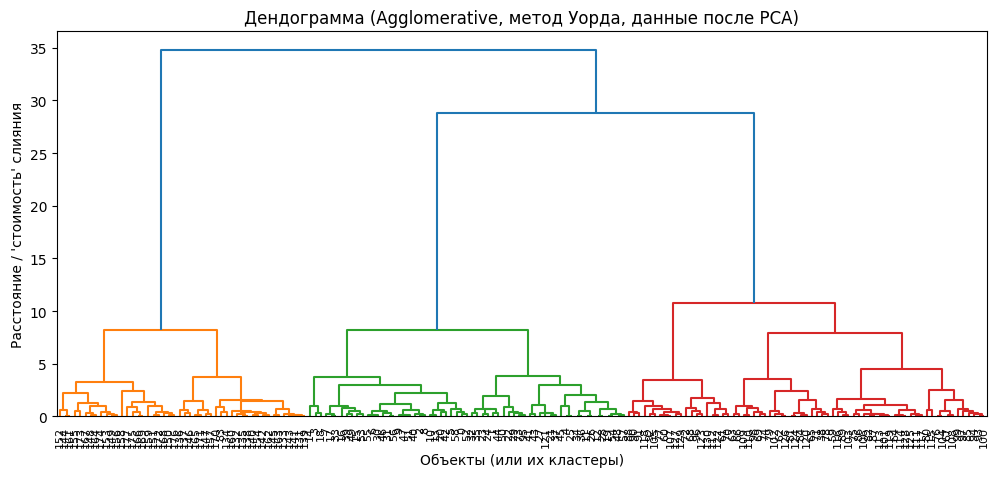

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from copy import deepcopy

# отдельный препроцессор только для дендрограммы,
# чтобы не трогать тот, что пойдёт в пайплайны
preprocess_dendro = deepcopy(preprocess)

X_tr = preprocess_dendro.fit_transform(X)
Z = linkage(X_tr, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
)
plt.title("Дендограмма (Agglomerative, метод Уорда, данные после PCA)")
plt.xlabel("Объекты (или их кластеры)")
plt.ylabel("Расстояние / 'стоимость' слияния")
plt.show()

4. Кластеризация через пайплайны

4.1. Пайплайн для KMeans

In [8]:
from copy import deepcopy

# Базовый пайплайн: предобработка + кластеризация
pipe_kmeans = Pipeline([
    ('preprocess', deepcopy(preprocess)),  # копия, чтобы не путать состояния
    ('cluster', KMeans(random_state=42, n_init=10))
])

k_range = range(2, 11)
kmeans_pipelines = {}
sil_scores_kmeans = []

for k in k_range:
    pipe_kmeans.set_params(cluster__n_clusters=k)
    pipe_kmeans.fit(X)

    # Получаем преобразованные признаки (после preprocess) для расчёта метрик
    X_tr = pipe_kmeans.named_steps['preprocess'].transform(X)
    labels = pipe_kmeans.named_steps['cluster'].labels_

    sil = silhouette_score(X_tr, labels)
    sil_scores_kmeans.append(sil)
    kmeans_pipelines[k] = deepcopy(pipe_kmeans)

    print(f"KMeans: k = {k}, silhouette = {sil:.4f}")

KMeans: k = 2, silhouette = 0.4649
KMeans: k = 3, silhouette = 0.5611
KMeans: k = 4, silhouette = 0.4914
KMeans: k = 5, silhouette = 0.4391
KMeans: k = 6, silhouette = 0.4334
KMeans: k = 7, silhouette = 0.4222
KMeans: k = 8, silhouette = 0.4072
KMeans: k = 9, silhouette = 0.3994
KMeans: k = 10, silhouette = 0.4016


График силуэта + выбор лучшего k:

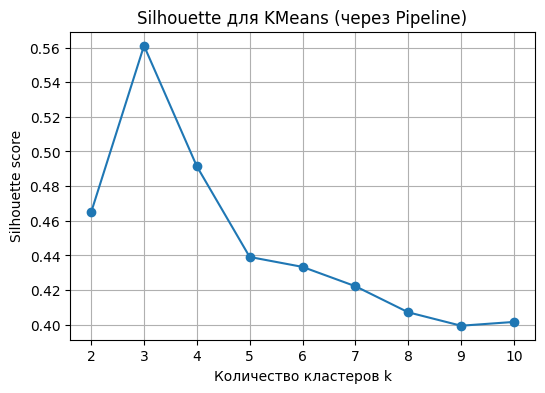

Лучшее k для KMeans по силуэту: 3


In [9]:
plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores_kmeans, marker='o')
plt.xlabel("Количество кластеров k")
plt.ylabel("Silhouette score")
plt.title("Silhouette для KMeans (через Pipeline)")
plt.grid(True)
plt.show()

best_k_kmeans = k_range[int(np.argmax(sil_scores_kmeans))]
print("Лучшее k для KMeans по силуэту:", best_k_kmeans)

best_kmeans_pipeline = kmeans_pipelines[best_k_kmeans]

4.2. Пайплайн для AgglomerativeClustering

In [10]:
pipe_agg = Pipeline([
    ('preprocess', deepcopy(preprocess)),
    ('cluster', AgglomerativeClustering(linkage='ward'))
])

agg_pipelines = {}
sil_scores_agg = []

for k in k_range:
    pipe_agg.set_params(cluster__n_clusters=k)
    pipe_agg.fit(X)

    X_tr = pipe_agg.named_steps['preprocess'].transform(X)
    labels = pipe_agg.named_steps['cluster'].labels_

    sil = silhouette_score(X_tr, labels)
    sil_scores_agg.append(sil)
    agg_pipelines[k] = deepcopy(pipe_agg)

    print(f"Agglomerative: k = {k}, silhouette = {sil:.4f}")

Agglomerative: k = 2, silhouette = 0.4736
Agglomerative: k = 3, silhouette = 0.5591
Agglomerative: k = 4, silhouette = 0.4813
Agglomerative: k = 5, silhouette = 0.3898
Agglomerative: k = 6, silhouette = 0.3810
Agglomerative: k = 7, silhouette = 0.3985
Agglomerative: k = 8, silhouette = 0.3935
Agglomerative: k = 9, silhouette = 0.3810
Agglomerative: k = 10, silhouette = 0.3744


График и лучший k:

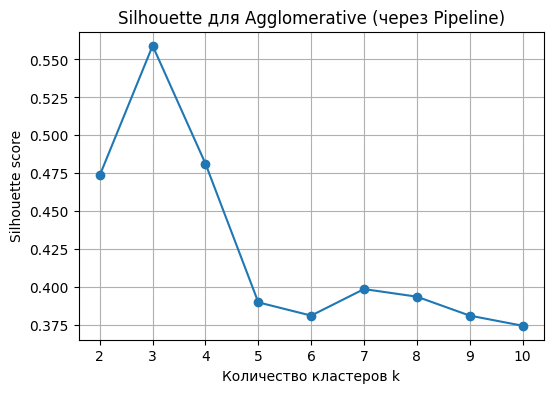

Лучшее k для Agglomerative по силуэту: 3


In [11]:
plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores_agg, marker='o')
plt.xlabel("Количество кластеров k")
plt.ylabel("Silhouette score")
plt.title("Silhouette для Agglomerative (через Pipeline)")
plt.grid(True)
plt.show()

best_k_agg = k_range[int(np.argmax(sil_scores_agg))]
print("Лучшее k для Agglomerative по силуэту:", best_k_agg)

best_agg_pipeline = agg_pipelines[best_k_agg]

4.3. Пайплайн для DBSCAN (подбор eps и min_samples)

In [12]:
pipe_dbscan = Pipeline([
    ('preprocess', deepcopy(preprocess)),
    ('cluster', DBSCAN())
])

eps_values = [0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_values = [3, 5, 7]

best_dbscan_pipeline = None
best_sil_dbscan = -1
best_params_dbscan = None

for eps in eps_values:
    for ms in min_samples_values:
        pipe_dbscan.set_params(cluster__eps=eps, cluster__min_samples=ms)
        pipe_dbscan.fit(X)

        X_tr = pipe_dbscan.named_steps['preprocess'].transform(X)
        labels = pipe_dbscan.named_steps['cluster'].labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters <= 1:
            continue

        sil = silhouette_score(X_tr, labels)
        print(f"DBSCAN: eps={eps}, min_samples={ms}, clusters={n_clusters}, silhouette={sil:.4f}")

        if sil > best_sil_dbscan:
            best_sil_dbscan = sil
            best_dbscan_pipeline = deepcopy(pipe_dbscan)
            best_params_dbscan = (eps, ms)

print("\nЛучший DBSCAN:", best_params_dbscan, "silhouette =", best_sil_dbscan)

DBSCAN: eps=0.5, min_samples=3, clusters=6, silhouette=0.2732
DBSCAN: eps=0.5, min_samples=5, clusters=5, silhouette=0.3230
DBSCAN: eps=0.5, min_samples=7, clusters=6, silhouette=0.1027
DBSCAN: eps=0.7, min_samples=5, clusters=2, silhouette=0.3522
DBSCAN: eps=0.7, min_samples=7, clusters=2, silhouette=0.3507

Лучший DBSCAN: (0.7, 5) silhouette = 0.3521598537751894


5. Функция оценки качества для пайплайнов

In [13]:
def evaluate_pipeline(pipe, X, name="model"):
    """
    Оценивает качество кластеризации пайплайна:
    - fit на X
    - берёт преобразованные признаки после 'preprocess'
    - вычисляет silhouette, Davies–Bouldin, Calinski–Harabasz
    """
    pipe.fit(X)
    X_tr = pipe.named_steps['preprocess'].transform(X)
    labels = pipe.named_steps['cluster'].labels_

    sil = silhouette_score(X_tr, labels)
    db = davies_bouldin_score(X_tr, labels)
    ch = calinski_harabasz_score(X_tr, labels)

    print(f"{name}:")
    print(f"  Silhouette score:        {sil:.4f}")
    print(f"  Davies–Bouldin index:    {db:.4f}")
    print(f"  Calinski–Harabasz score: {ch:.2f}")
    print()

Оцениваем лучшие пайплайны:

In [14]:
evaluate_pipeline(best_kmeans_pipeline, X, name=f"KMeans Pipeline (k={best_k_kmeans})")
evaluate_pipeline(best_agg_pipeline, X, name=f"Agglomerative Pipeline (k={best_k_agg})")

if best_dbscan_pipeline is not None:
    # нельзя просто вызывать evaluate_pipeline, потому что для DBSCAN бывает 1 кластер + шум
    best_dbscan_pipeline.fit(X)
    X_tr = best_dbscan_pipeline.named_steps['preprocess'].transform(X)
    labels = best_dbscan_pipeline.named_steps['cluster'].labels_
    n_clusters_db = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters_db > 1:
        evaluate_pipeline(best_dbscan_pipeline, X,
                          name=f"DBSCAN Pipeline (eps={best_params_dbscan[0]}, min_samples={best_params_dbscan[1]})")
    else:
        print("Лучший DBSCAN дал <=1 кластера, метрики считать некорректно.")

KMeans Pipeline (k=3):
  Silhouette score:        0.5611
  Davies–Bouldin index:    0.5973
  Calinski–Harabasz score: 344.79

Agglomerative Pipeline (k=3):
  Silhouette score:        0.5591
  Davies–Bouldin index:    0.6013
  Calinski–Harabasz score: 341.06

DBSCAN Pipeline (eps=0.7, min_samples=5):
  Silhouette score:        0.3522
  Davies–Bouldin index:    3.4654
  Calinski–Harabasz score: 75.38



6. Визуализация кластеров (через предобработочный пайплайн)

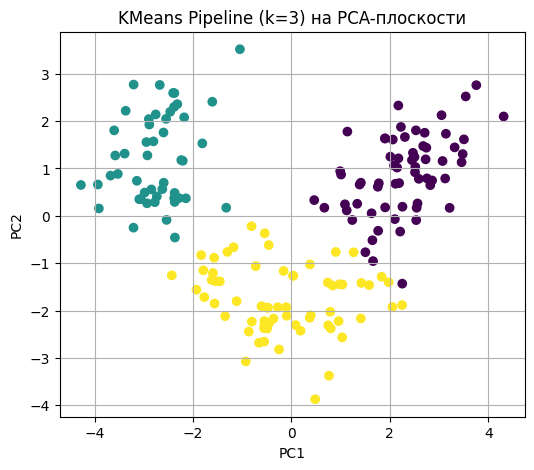

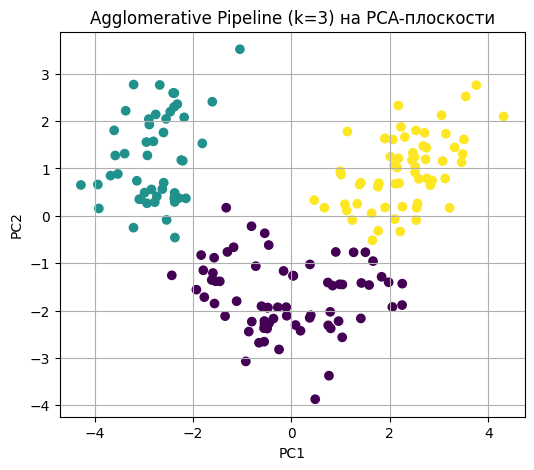

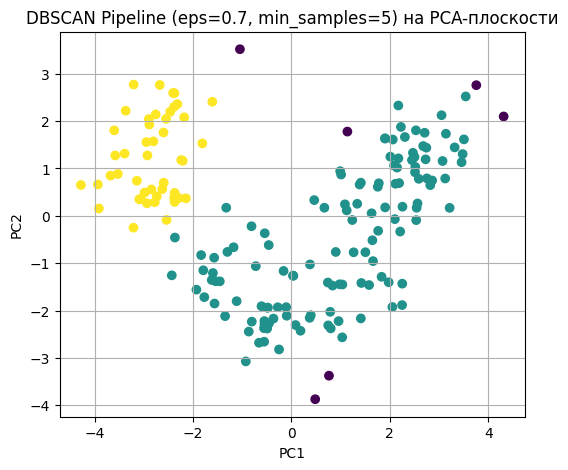

In [15]:
def plot_clusters_2d(X_2d, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# KMeans
best_kmeans_pipeline.fit(X)
labels_kmeans = best_kmeans_pipeline.named_steps['cluster'].labels_
plot_clusters_2d(X_pca, labels_kmeans, f"KMeans Pipeline (k={best_k_kmeans}) на PCA-плоскости")

# Agglomerative
best_agg_pipeline.fit(X)
labels_agg = best_agg_pipeline.named_steps['cluster'].labels_
plot_clusters_2d(X_pca, labels_agg, f"Agglomerative Pipeline (k={best_k_agg}) на PCA-плоскости")

# DBSCAN (если разумное число кластеров)
if best_dbscan_pipeline is not None:
    best_dbscan_pipeline.fit(X)
    labels_db = best_dbscan_pipeline.named_steps['cluster'].labels_
    n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

    if n_clusters_db > 1:
        plot_clusters_2d(X_pca, labels_db,
                         f"DBSCAN Pipeline (eps={best_params_dbscan[0]}, min_samples={best_params_dbscan[1]}) на PCA-плоскости")

Для числа кластеров k=3 были рассчитаны показатели качества кластеризации для трёх алгоритмов. Модели KMeans и агломеративной кластеризации продемонстрировали близкие и достаточно высокие значения коэффициента силуэта (0.561 и 0.559 соответственно), низкий индекс Дэвиса–Боулдина (0.6) и высокие значения индекса Калински–Харабаса (340), что свидетельствует о компактности и хорошем разделении кластеров.
Алгоритм DBSCAN при выбранных параметрах (eps = 0.7, min_samples = 5) показал значительно худшие результаты (silhouette = 0.35, Davies–Bouldin ≈ 3.47, Calinski–Harabasz ≈ 75), поэтому его качество кластеризации на данном наборе данных существенно уступает методам KMeans и агломеративной кластеризации. В дальнейшем в качестве основной модели кластеризации целесообразно рассматривать KMeans с k=3 кластеров.